In [114]:
import torch
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms as T
from sklearn.utils.class_weight import compute_class_weight


In [116]:
class CNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=3):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv1_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1_2 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv2_2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2_2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv3_2 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3_2 = nn.BatchNorm2d(128)

        self.dropout2d = nn.Dropout2d(p=0.2)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # self.pool = nn.AvgPool2d(kernel_size=2, stride=2)    

        self.fc1 = nn.Linear(128 * 28 * 28, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)

        self.dropout = nn.Dropout(p=0.4)

        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout2d(x)

        x = self.conv1_2(x)
        x = self.bn1_2(x)
        x = F.relu(x)
        x = self.pool(x)


        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2d(x)

        x = self.conv2_2(x)
        x = self.bn2_2(x)
        x = F.relu(x)
        x = self.pool(x)


        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout2d(x)

        x = self.conv3_2(x)
        x = self.bn3_2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = x.reshape(x.shape[0], -1) 

        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [117]:
class ImageDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('L')
        
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
            
        return image, label

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(20),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

data_dir = Path('Breast-Cancer-Dataset')
classes = [d.name for d in data_dir.iterdir() if d.is_dir()]
label_map = {name: i for i, name in enumerate(classes)}
num_classes = len(classes)

print(f"Clases encontradas: {label_map}")

file_paths = []
labels = []
for class_name, label_idx in label_map.items():
    class_dir = data_dir / class_name
    for img_path in class_dir.glob('*.[jp][pn]g'): 
        file_paths.append(str(img_path))
        labels.append(label_idx)

print(f"Total de imágenes encontradas: {len(file_paths)}")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, 
    labels, 
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_dataset = ImageDataset(train_paths, train_labels, transform=train_transform)
val_dataset = ImageDataset(val_paths, val_labels, transform=val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Imágenes de entreno: {len(train_dataset)}")
print(f"Imágenes de validación: {len(val_dataset)}")


Clases encontradas: {'benign': 0, 'malignant': 1, 'normal': 2}
Total de imágenes encontradas: 780
Imágenes de entreno: 624
Imágenes de validación: 156


In [118]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')
print("=== Empezando entrenamiento: Modelo base ===")

model = CNN(in_channels=1, num_classes=num_classes).to(device)

learning_rate = 0.001
NUM_EPOCHS = 50

# Balanceo de clases
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.FloatTensor(class_weights).to(device)
print(f"Pesos de clases: {class_weights}")  # ← AÑADE ESTO para verificar

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)  # ← Añade weight_decay

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

best_val_loss = float('inf')
best_val_acc = 0.0  # ← AÑADE ESTO para trackear
patience = 7  # ← Aumenta de 5 a 7
patience_counter = 0
best_model_path = "best_model.pth"

print(f"\nIniciando entrenamiento con early stopping (patience={patience})")
print("-" * 80)

for epoch in range(NUM_EPOCHS):   
    # ========== FASE DE ENTRENAMIENTO ==========
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]'):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # ✅ CORREGIDO: Multiplica por tamaño del batch
        running_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # ✅ CORREGIDO: Divide entre total de imágenes
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = 100 * correct_train / total_train
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)

    # ========== FASE DE VALIDACIÓN ==========
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # ✅ CORREGIDO: Multiplica por tamaño del batch
            running_val_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # ✅ CORREGIDO: Divide entre total de imágenes
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = 100 * correct_val / total_val
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # ========== IMPRIMIR MÉTRICAS ==========
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | '
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')
    
    # ========== EARLY STOPPING ==========
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_val_acc = epoch_val_acc  # ← AÑADE ESTO
        patience_counter = 0
        
        # Guarda el mejor modelo
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': epoch_val_loss,
            'val_acc': epoch_val_acc,
            'history': history
        }, best_model_path)
        
        print(f"  ✓ Mejor modelo guardado (val_loss: {epoch_val_loss:.4f}, val_acc: {epoch_val_acc:.2f}%)")
    else:
        patience_counter += 1
        print(f"  ⚠ Sin mejora. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n⛔ Early stopping activado en época {epoch+1}")
            print(f"   Mejor época fue: {epoch+1-patience}")
            break

print('\n' + '='*80)
print('Entrenamiento finalizado.')

# ✅ AÑADE ESTO: Cargar el mejor modelo
print("\n🔄 Cargando el mejor modelo...")
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Mejor modelo cargado:")
print(f"  - Época: {checkpoint['epoch']+1}")
print(f"  - Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  - Val Acc: {checkpoint['val_acc']:.2f}%")
print('='*80)

Usando dispositivo: cpu
=== Empezando entrenamiento: Modelo base ===
Pesos de clases: tensor([0.5943, 1.2381, 1.9623])

Iniciando entrenamiento con early stopping (patience=7)
--------------------------------------------------------------------------------


Epoch 1/50 [Val]: 100%|██████████| 5/5 [00:08<00:00,  1.68s/it]


Epoch [1/50] - Train Loss: 1.1753, Train Acc: 43.43% | Val Loss: 1.6673, Val Acc: 26.92%
  ✓ Mejor modelo guardado (val_loss: 1.6673, val_acc: 26.92%)


Epoch 2/50 [Val]: 100%|██████████| 5/5 [00:09<00:00,  1.99s/it]


Epoch [2/50] - Train Loss: 1.0788, Train Acc: 47.28% | Val Loss: 1.1272, Val Acc: 28.85%
  ✓ Mejor modelo guardado (val_loss: 1.1272, val_acc: 28.85%)


...

Epoch [26/50] - Train Loss: 0.5107, Train Acc: 78.21% | Val Loss: 0.5983, Val Acc: 75.00%
  ⚠ Sin mejora. Patience: 5/7


Epoch 27/50 [Val]: 100%|██████████| 5/5 [00:08<00:00,  1.78s/it]


Epoch [27/50] - Train Loss: 0.5012, Train Acc: 76.92% | Val Loss: 0.6127, Val Acc: 77.56%
  ⚠ Sin mejora. Patience: 6/7


Epoch 28/50 [Val]: 100%|██████████| 5/5 [00:08<00:00,  1.62s/it]

Epoch [28/50] - Train Loss: 0.4572, Train Acc: 80.93% | Val Loss: 0.6359, Val Acc: 72.44%
  ⚠ Sin mejora. Patience: 7/7

⛔ Early stopping activado en época 28
   Mejor época fue: 21

Entrenamiento finalizado.

🔄 Cargando el mejor modelo...
✓ Mejor modelo cargado:
  - Época: 21
  - Val Loss: 0.5796
  - Val Acc: 75.64%


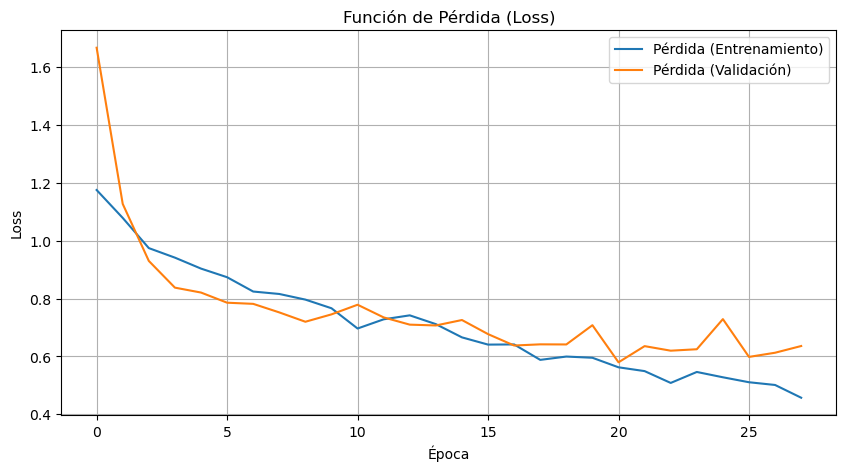

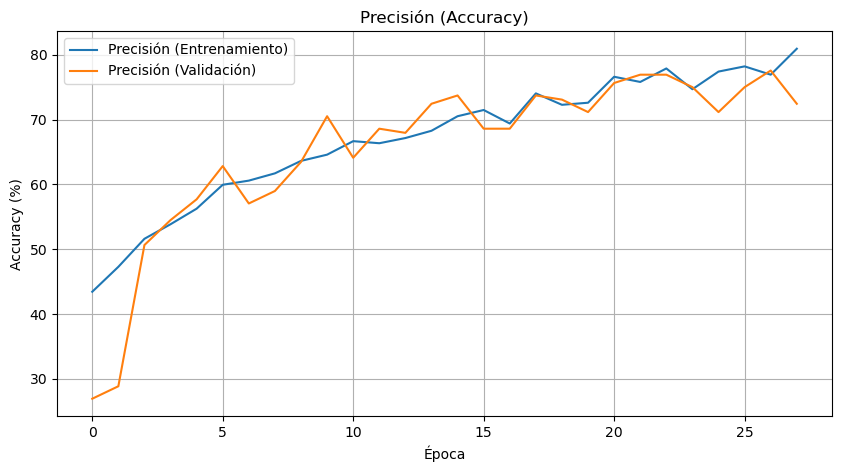

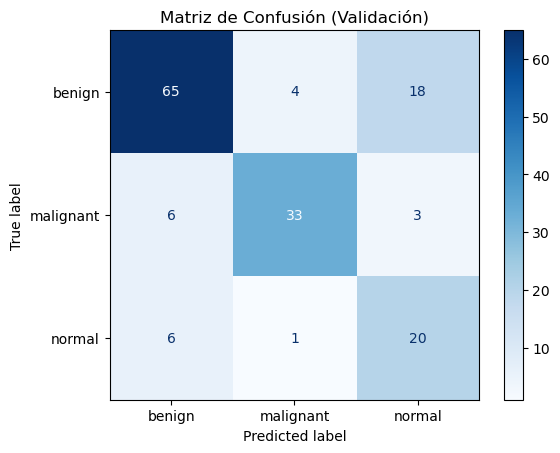

In [119]:
# Importa esto si no lo tienes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Gráfica de Pérdida (Loss) ---
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Pérdida (Entrenamiento)')
plt.plot(history['val_loss'], label='Pérdida (Validación)')
plt.title('Función de Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Gráfica de Precisión (Accuracy) ---
plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Precisión (Entrenamiento)')
plt.plot(history['val_acc'], label='Precisión (Validación)')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


# --- Matriz de Confusión ---
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calcula la matriz
cm = confusion_matrix(all_labels, all_preds)

# Muestra la matriz (usando los nombres de las clases)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Validación)')
plt.show()

In [22]:
# --- PASO 5: IMPLEMENTAR TRANSFER LEARNING (Modelo 5) ---

import torchvision.models as models

print("--- Configurando Modelo 5: Transfer Learning (ResNet18) ---")

# --- 1. Cargar el ResNet18 pre-entrenado ---
# pretrained=True descarga los pesos aprendidos en ImageNet
model_tl = models.resnet18(pretrained=True)

# --- 2. Congelar todos los pesos del modelo ---
# No queremos re-entrenar el modelo, solo la capa final.
print("Congelando todas las capas del modelo...")
for param in model_tl.parameters():
    param.requires_grad = False

# --- 3. Reemplazar la última capa (el "Clasificador") ---
# ResNet18 fue entrenado para 1000 clases (ImageNet).
# Lo reemplazamos por una nueva capa para nuestras 'num_classes' (que es 3).

# Obtenemos el número de "neuronas" de entrada a la última capa
num_features = model_tl.fc.in_features 
print(f"Número de features de entrada a la última capa: {num_features}") # (Suele ser 512)

# Creamos nuestra nueva capa.
# Esta nueva capa SÍ tendrá requires_grad=True (la única que entrenará)
model_tl.fc = nn.Linear(num_features, num_classes)

# --- 4. Mover el modelo al dispositivo ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_tl = model_tl.to(device)

print("¡Modelo ResNet18 listo para Transfer Learning!")

--- Configurando Modelo 5: Transfer Learning (ResNet18) ---


c:\Users\Juan Diego\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Juan Diego\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Congelando todas las capas del modelo...
Número de features de entrada a la última capa: 512
¡Modelo ResNet18 listo para Transfer Learning!


In [23]:
# --- Configuración del Entrenamiento para el Modelo 5 ---

# --- Instanciar el Modelo 5 ---
model = model_tl 

# --- Hiperparámetros ---
learning_rate = 0.001
NUM_EPOCHS = 25 # 25 épocas deberían ser suficientes

# --- Definir la función de pérdida ---
criterion = nn.CrossEntropyLoss()

# --- ¡¡¡CAMBIO CRÍTICO: EL OPTIMIZADOR!!! ---
#
# Solo le pasamos al optimizador los parámetros
# de la capa que SÍ queremos entrenar (model.fc).
#
optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)

# --- Historial para las gráficas ---
# (Reseteamos el historial para este nuevo modelo)
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("Optimizador configurado. Listo para entrenar la capa final.")

Optimizador configurado. Listo para entrenar la capa final.


In [24]:
# --- Bucle Principal de Entrenamiento ---
# (Esta celda usará automáticamente el 'model' y 'optimizer' que definimos antes)

print("Iniciando entrenamiento del Modelo 5 (Transfer Learning)...")

for epoch in range(NUM_EPOCHS):
    
    # --- Fase de Entrenamiento ---
    model.train() # Poner modelo en modo entrenamiento
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]'):
        images, labels = images.to(device), labels.to(device)
        
        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 2. Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)

    # --- Fase de Validación ---
    model.eval() # Poner modelo en modo evaluación
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # No calcular gradientes
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = 100 * correct_val / total_val
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, '
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

print('Entrenamiento finalizado.')

Iniciando entrenamiento del Modelo 5 (Transfer Learning)...


Epoch 1/25 [Val]: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]


Epoch [1/25], Train Loss: 1.0176, Train Acc: 51.60%, Val Loss: 0.9153, Val Acc: 60.90%


Epoch 2/25 [Val]: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]


Epoch [2/25], Train Loss: 0.9053, Train Acc: 58.33%, Val Loss: 0.8711, Val Acc: 62.82%


...

Epoch [23/25], Train Loss: 0.5791, Train Acc: 76.44%, Val Loss: 0.5904, Val Acc: 75.00%


Epoch 24/25 [Val]: 100%|██████████| 5/5 [00:07<00:00,  1.56s/it]


Epoch [24/25], Train Loss: 0.5650, Train Acc: 75.32%, Val Loss: 0.5693, Val Acc: 78.85%


Epoch 25/25 [Val]: 100%|██████████| 5/5 [00:07<00:00,  1.54s/it]

Epoch [25/25], Train Loss: 0.5558, Train Acc: 77.08%, Val Loss: 0.5684, Val Acc: 78.21%
Entrenamiento finalizado.
